# Enviroment Setup:

In [1]:
import numpy as np
import pandas as pd
import os
import psutil
import time
import matplotlib.pyplot as plt
import torch
import pickle
import torch.nn as nn
from statistics import mean
from data_processors.data_splitter_new import DataSplitter as DataSplitter_new
from models.LSTM import train_and_eval
from models.ConsciousLSTM import train_and_eval as conscious_train_and_eval

session_ids = [
    715093703,
    719161530,
    721123822,
    732592105,
    737581020,
    739448407,
    742951821,
    743475441,
    744228101,
    746083955,
    750332458,
    750749662,
    751348571,
    754312389,
    754829445,
    755434585,
    756029989,
    757216464,
    757970808,
    758798717,
    759883607,
    760345702,
    760693773,
    761418226,
    762120172,
    762602078,
    763673393,
    773418906,
    791319847,
    797828357,
    798911424,
    799864342,
]

if torch.cuda.is_available():
    print("CUDA GPU is available.")
    device = torch.device('cuda')
else:
    print("CUDA GPU is not available. Using CPU instead.")
    device = torch.device('cpu')
    
print(f"Current GPU device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
print(f"Total RAM: {(psutil.virtual_memory().total / (1024**3)):.2f} GB")
print(f"Available RAM: {(psutil.virtual_memory().available / (1024**3)):.2f} GB")

CUDA GPU is available.
Current GPU device: NVIDIA A100-PCIE-40GB MIG 2g.10gb
Total RAM: 1006.97 GB
Available RAM: 942.49 GB


# Identify optimal epoch for baseline LSTM and cLSTM:


=== Training session 715093703 ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
Epoch 1/15 | Train Acc: 13.00% | Val/Test Acc: 39.08%
Epoch 2/15 | Train Acc: 75.28% | Val/Test Acc: 76.05%
Epoch 3/15 | Train Acc: 87.84% | Val/Test Acc: 79.41%
Epoch 4/15 | Train Acc: 88.26% | Val/Test Acc: 81.30%
Epoch 5/15 | Train Acc: 88.33% | Val/Test Acc: 81.51%
Epoch 6/15 | Train Acc: 88.35% | Val/Test Acc: 81.51%
Epoch 7/15 | Train Acc: 88.28% | Val/Test Acc: 81.51%
Epoch 8/15 | Train Acc: 88.28% | Val/Test Acc: 81.72%
Epoch 9/15 | Train Acc: 88.38% | Val/Test Acc: 81.51%
Epoch 10/15 | Train Acc: 88.38% | Val/Test Acc: 81.51%
Epoch 11/15 | Train Acc: 88.26% | Val/Test Acc: 81.51%
Epoch 12/15 | Train Acc: 88.28% | Val/Test Acc: 81.51%
Epoch 13/15 | Train Acc: 88.31% | Val/Test Acc: 81.51%
Epoch 1

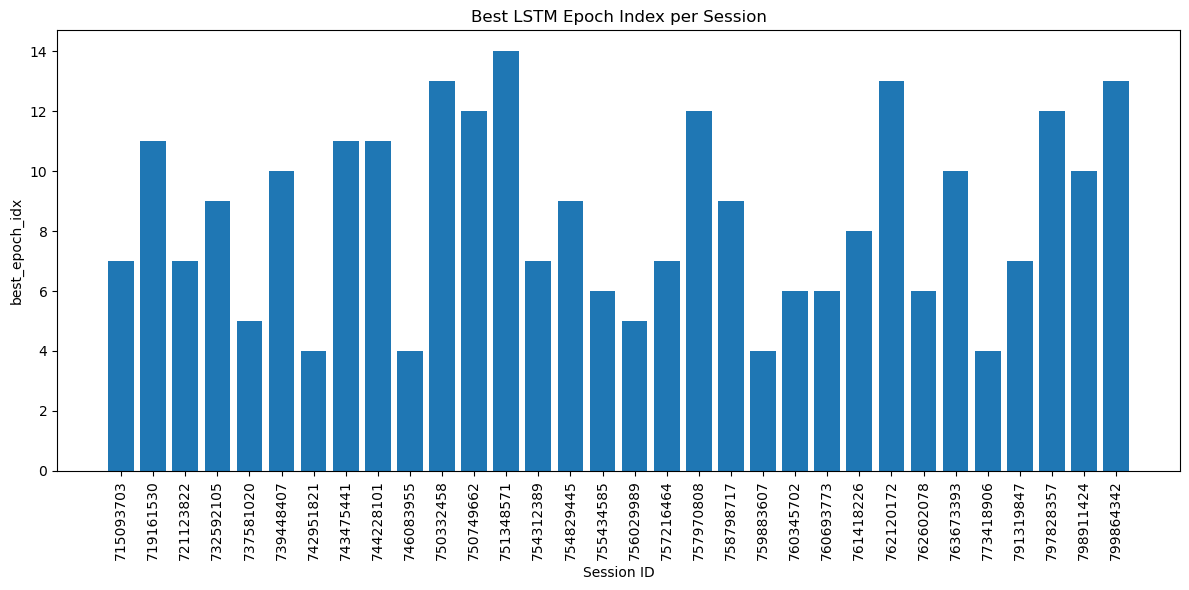


Average best_epoch_idx across sessions: 8.50


In [2]:
best_epoch_idx_dict = {}
best_val_acc_dict = {}

for sid in session_ids:
    print(f"\n=== Training session {sid} ===")

    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)

    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)

    best_epoch_idx, best_val_acc, _ = train_and_eval(
        hidden_dim=1000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=15,
        data_splitter=data_splitter,
    )

    best_epoch_idx_dict[sid] = best_epoch_idx
    best_val_acc_dict[sid] = best_val_acc

session_labels = [str(sid) for sid in session_ids]
best_epochs = [best_epoch_idx_dict[sid] for sid in session_ids]

plt.figure(figsize=(12, 6))
plt.bar(session_labels, best_epochs)
plt.xticks(rotation=90)
plt.xlabel("Session ID")
plt.ylabel("best_epoch_idx")
plt.title("Best LSTM Epoch Index per Session")
plt.tight_layout()
plt.show()

avg_best_epoch_idx = sum(best_epochs) / len(best_epochs)
print(f"\nAverage best_epoch_idx across sessions: {avg_best_epoch_idx:.2f}")


=== Training session 715093703 ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
Epoch 1/15 | Train Acc: 1.59% | Val/Test Acc: 11.76%
Epoch 2/15 | Train Acc: 29.25% | Val/Test Acc: 53.57%
Epoch 3/15 | Train Acc: 79.41% | Val/Test Acc: 74.58%
Epoch 4/15 | Train Acc: 87.86% | Val/Test Acc: 80.25%
Epoch 5/15 | Train Acc: 88.31% | Val/Test Acc: 81.72%
Epoch 6/15 | Train Acc: 88.28% | Val/Test Acc: 81.93%
Epoch 7/15 | Train Acc: 88.26% | Val/Test Acc: 82.77%
Epoch 8/15 | Train Acc: 88.35% | Val/Test Acc: 81.72%
Epoch 9/15 | Train Acc: 88.35% | Val/Test Acc: 82.35%
Epoch 10/15 | Train Acc: 88.26% | Val/Test Acc: 82.14%
Epoch 11/15 | Train Acc: 88.28% | Val/Test Acc: 80.88%
Epoch 12/15 | Train Acc: 88.31% | Val/Test Acc: 82.35%
Epoch 13/15 | Train Acc: 88.26% | Val/Test Acc: 81.93%
Epoch 14

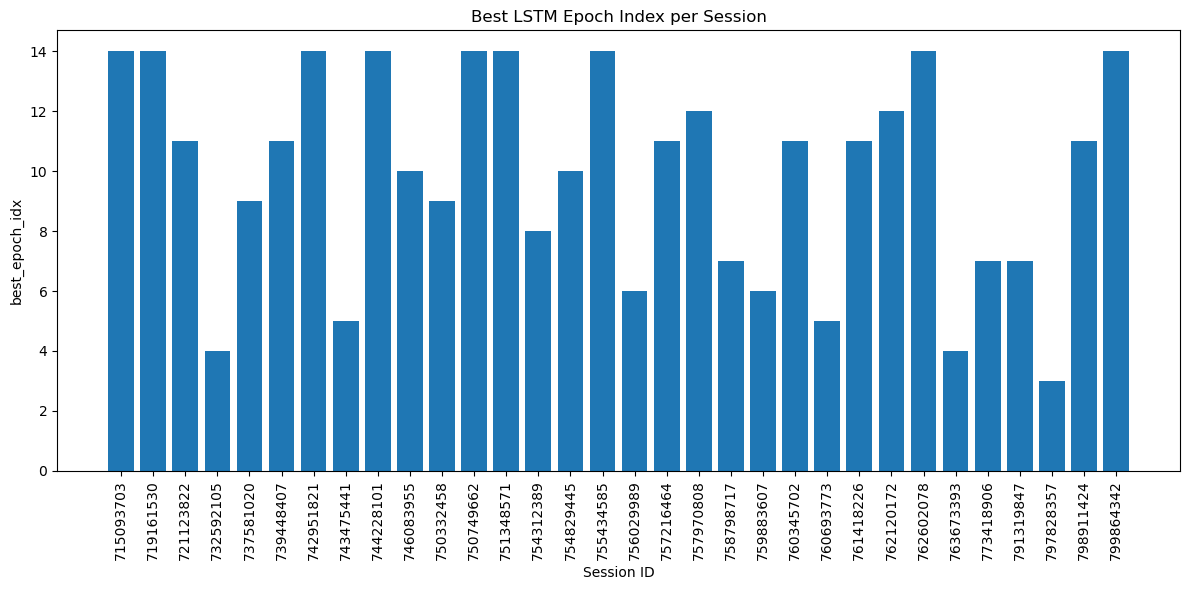


Average best_epoch_idx across sessions: 9.88


In [3]:
best_epoch_idx_dict = {}
best_val_acc_dict = {}

for sid in session_ids:
    print(f"\n=== Training session {sid} ===")

    spike_trains_file_path = f'output/spike_trains_with_stimulus_session_{sid}_5.pkl'
    with open(spike_trains_file_path, 'rb') as f:
        spike_df = pickle.load(f)
    
    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    best_epoch_idx, best_val_acc, _ = conscious_train_and_eval(
        hidden_dim=2000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=15,
        data_splitter=data_splitter,
        k=30,
        c=0.65
    )

    best_epoch_idx_dict[sid] = best_epoch_idx
    best_val_acc_dict[sid] = best_val_acc

session_labels = [str(sid) for sid in session_ids]
best_epochs = [best_epoch_idx_dict[sid] for sid in session_ids]

plt.figure(figsize=(12, 6))
plt.bar(session_labels, best_epochs)
plt.xticks(rotation=90)
plt.xlabel("Session ID")
plt.ylabel("best_epoch_idx")
plt.title("Best LSTM Epoch Index per Session")
plt.tight_layout()
plt.show()

avg_best_epoch_idx = sum(best_epochs) / len(best_epochs)
print(f"\nAverage best_epoch_idx across sessions: {avg_best_epoch_idx:.2f}")

# Train baseline LSTM and cLSTM 3 times for each mouse and compare performance:

In [4]:
avg_final_epoch_acc_list_b = []

for sid in session_ids:
    print(f"\n=== Training session {sid} (3 runs) ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)
    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    final_epoch_accs = []
    
    for run in range(3):
        print(f"  Run {run + 1}/3")
        best_epoch_idx, best_val_acc, final_epoch_acc = train_and_eval(
            hidden_dim=1000,
            layer_dim=1,
            learning_rate=0.001,
            num_epochs=9,
            data_splitter=data_splitter,
            validation=False
        )
        final_epoch_accs.append(final_epoch_acc)

    avg_final_acc = sum(final_epoch_accs) / len(final_epoch_accs)
    avg_final_epoch_acc_list_b.append(avg_final_acc)
    print(f"Session {sid}: average final epoch accuracy over 3 runs = {avg_final_acc:.4f}")


=== Training session 715093703 (3 runs) ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
  Run 1/3
Epoch 1/9 | Train Acc: 13.00% | Val/Test Acc: 37.39%
Epoch 2/9 | Train Acc: 75.42% | Val/Test Acc: 72.77%
Epoch 3/9 | Train Acc: 87.86% | Val/Test Acc: 72.10%
Epoch 4/9 | Train Acc: 88.28% | Val/Test Acc: 77.73%
Epoch 5/9 | Train Acc: 88.33% | Val/Test Acc: 77.98%
Epoch 6/9 | Train Acc: 88.31% | Val/Test Acc: 78.24%
Epoch 7/9 | Train Acc: 88.31% | Val/Test Acc: 77.98%
Epoch 8/9 | Train Acc: 88.28% | Val/Test Acc: 78.07%
Epoch 9/9 | Train Acc: 88.35% | Val/Test Acc: 78.24%
Best epoch: 5 | Best Val Acc: 78.24%
  Run 2/3
Epoch 1/9 | Train Acc: 15.17% | Val/Test Acc: 41.09%
Epoch 2/9 | Train Acc: 76.87% | Val/Test Acc: 73.19%
Epoch 3/9 | Train Acc: 87.98% | Val/Test Acc: 75.63%
Epoch 4/9 |

In [5]:
avg_final_epoch_acc_list_c = []

for sid in session_ids:
    print(f"\n=== Training session {sid} (3 runs) ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)
    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    final_epoch_accs = []
    
    for run in range(3):
        print(f"  Run {run + 1}/3")
        best_epoch_idx, best_val_acc, final_epoch_acc = conscious_train_and_eval(
            hidden_dim=2000,
            layer_dim=1,
            learning_rate=0.001,
            num_epochs=9,
            data_splitter=data_splitter,
            k=30,
            c=0.1,
            validation=False
        )
        final_epoch_accs.append(final_epoch_acc)

    avg_final_acc = sum(final_epoch_accs) / len(final_epoch_accs)
    avg_final_epoch_acc_list_c.append(avg_final_acc)
    print(f"Session {sid}: average final epoch accuracy over 3 runs = {avg_final_acc:.4f}")


=== Training session 715093703 (3 runs) ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
  Run 1/3
Epoch 1/9 | Train Acc: 10.06% | Val/Test Acc: 37.98%
Epoch 2/9 | Train Acc: 71.06% | Val/Test Acc: 71.18%
Epoch 3/9 | Train Acc: 87.21% | Val/Test Acc: 75.04%
Epoch 4/9 | Train Acc: 88.21% | Val/Test Acc: 77.98%
Epoch 5/9 | Train Acc: 88.28% | Val/Test Acc: 77.56%
Epoch 6/9 | Train Acc: 88.28% | Val/Test Acc: 78.15%
Epoch 7/9 | Train Acc: 88.35% | Val/Test Acc: 78.07%
Epoch 8/9 | Train Acc: 88.26% | Val/Test Acc: 78.07%
Epoch 9/9 | Train Acc: 88.26% | Val/Test Acc: 78.24%
Best epoch: 8 | Best Val Acc: 78.24%
  Run 2/3
Epoch 1/9 | Train Acc: 10.64% | Val/Test Acc: 37.56%
Epoch 2/9 | Train Acc: 72.22% | Val/Test Acc: 72.61%
Epoch 3/9 | Train Acc: 87.25% | Val/Test Acc: 74.71%
Epoch 4/9 |

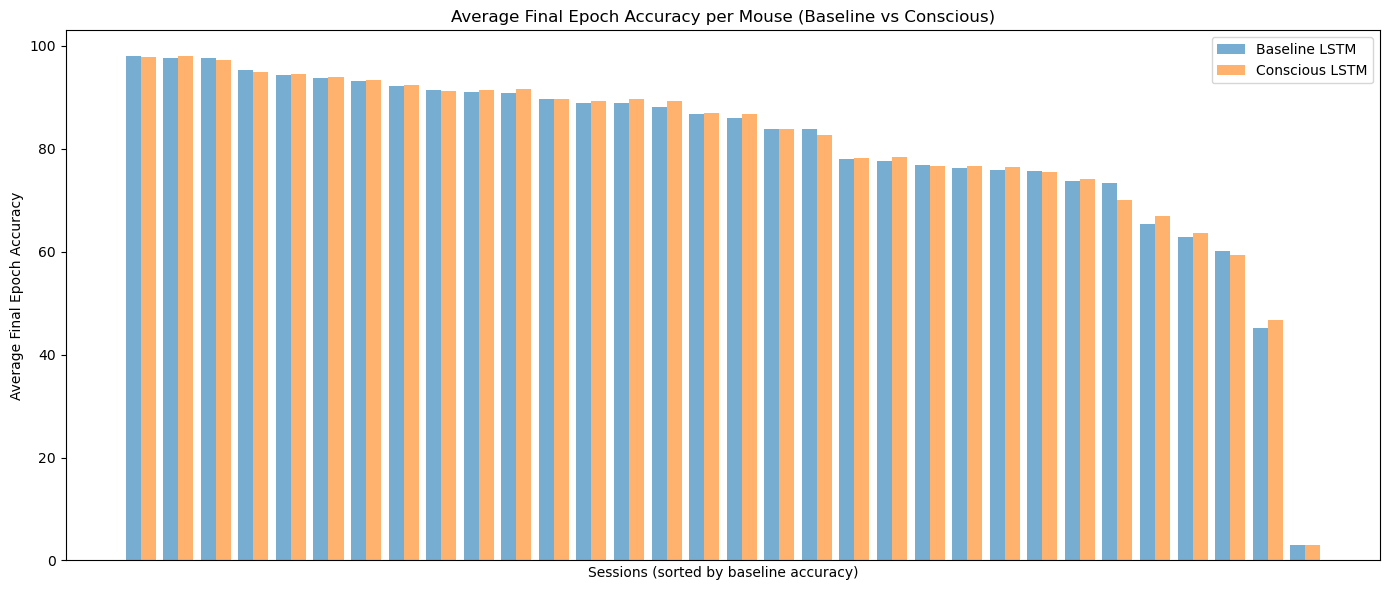

Difference: 0.15411860010277678


In [6]:
sorted_indices = sorted(
    range(len(session_ids)),
    key=lambda i: avg_final_epoch_acc_list_b[i],
    reverse=True
)

baseline_sorted   = [avg_final_epoch_acc_list_b[i] for i in sorted_indices]
conscious_sorted  = [avg_final_epoch_acc_list_c[i] for i in sorted_indices]

x = np.arange(len(baseline_sorted))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    baseline_sorted,
    width=width,
    alpha=0.6,
    label="Baseline LSTM",
)

plt.bar(
    x + width/2,
    conscious_sorted,
    width=width,
    alpha=0.6,
    label="Conscious LSTM",
)

plt.xticks([])
plt.xlabel("Sessions (sorted by baseline accuracy)")
plt.ylabel("Average Final Epoch Accuracy")
plt.title("Average Final Epoch Accuracy per Mouse (Baseline vs Conscious)")
plt.legend()
plt.tight_layout()
plt.show()

avg1 = sum(avg_final_epoch_acc_list_b) / len(avg_final_epoch_acc_list_b)
avg2 = sum(avg_final_epoch_acc_list_c) / len(avg_final_epoch_acc_list_c)
difference = avg2 - avg1
print("Difference:", difference)

# Compute performance metrics:

### Average feature dimension:

In [7]:
cols_minus_one = []
found_ids = []

for sid in session_ids:
    fpath = os.path.join(f"output/spike_trains_with_stimulus_session_{sid}_5.pkl")
    with open(fpath, "rb") as f:
        obj = pickle.load(f)

    if isinstance(obj, pd.DataFrame):
        n = obj.shape[1] - 1

    cols_minus_one.append(n)
    found_ids.append(sid)

print("per-id (columns-1):", dict(zip(found_ids, cols_minus_one)))
avg_val = mean(cols_minus_one) if cols_minus_one else float("nan")
print(f"Average (across {len(cols_minus_one)} files): {avg_val:.2f}")

per-id (columns-1): {715093703: 2073, 719161530: 1785, 721123822: 1191, 732592105: 2717, 737581020: 1453, 739448407: 1702, 742951821: 2164, 743475441: 1459, 744228101: 1781, 746083955: 1542, 750332458: 2118, 750749662: 1887, 751348571: 1985, 754312389: 1192, 754829445: 1791, 755434585: 1540, 756029989: 1641, 757216464: 2111, 757970808: 1867, 758798717: 1343, 759883607: 1347, 760345702: 1332, 760693773: 1785, 761418226: 1718, 762120172: 1642, 762602078: 1314, 763673393: 1750, 773418906: 1393, 791319847: 1445, 797828357: 1610, 798911424: 1878, 799864342: 1551}
Average (across 32 files): 1690.84


### Average MACs for baseline and cLSTM:

In [8]:
def estimate_lstm_model_macs(
    input_dim: int,
    hidden_dim: int,
    num_layers: int,
    output_dim: int,
    seq_len: int,
    batch_size: int,
) -> int:
    
    total_macs = 0

    for layer in range(num_layers):
        layer_input_dim = input_dim if layer == 0 else hidden_dim
        macs_per_timestep = 4 * (
            layer_input_dim * hidden_dim
            + hidden_dim * hidden_dim
            + hidden_dim
        )
        total_macs += batch_size * seq_len * macs_per_timestep
        
    fc_macs = batch_size * (hidden_dim * output_dim + output_dim)
    total_macs += fc_macs
    
    return total_macs

input_dim   = 1690
hidden_dim  = 1000
num_layers  = 1
output_dim  = 118
seq_len     = 5
batch_size  = 64

macs  = estimate_lstm_model_macs(input_dim, hidden_dim, num_layers,
                                 output_dim, seq_len, batch_size)
print(f"Baseline LSTM ~ MACs: {macs:,}")

Baseline LSTM ~ MACs: 3,452,039,552


In [9]:
def estimate_conscious_module_macs_per_call(
    hidden_dim: int,
    k: int,
) -> int:
    d = hidden_dim
    mid1 = max(1, d // 2)
    mid2 = max(1, d // 4)
    macs = 0
    macs += 3 * d
    macs += d * mid1 + mid1
    macs += mid1
    macs += mid1 * mid2 + mid2
    macs += mid2
    macs += mid2 * (d * k) + (d * k)
    macs += d * k
    return macs

def estimate_conscious_lstm_model_macs(
    input_dim: int,
    hidden_dim: int,
    num_layers: int,
    output_dim: int,
    seq_len: int,
    batch_size: int,
    k: int,
) -> int:
    
    total_macs = 0
    
    for layer in range(num_layers):
        layer_input_dim = input_dim if layer == 0 else hidden_dim

        macs_per_timestep = 4 * (
            layer_input_dim * hidden_dim
            + hidden_dim * hidden_dim
            + hidden_dim
        )
        total_macs += batch_size * seq_len * macs_per_timestep

    cm_macs_per_sample = estimate_conscious_module_macs_per_call(
        hidden_dim, k
    )
    total_macs += batch_size * seq_len * num_layers * cm_macs_per_sample
    fc_macs = batch_size * (hidden_dim * output_dim + output_dim)
    total_macs += fc_macs

    return total_macs



input_dim   = 1690
hidden_dim  = 2000
num_layers  = 1
output_dim  = 118
seq_len     = 5
batch_size  = 64
k           = 30

macs_con   = estimate_conscious_lstm_model_macs(
    input_dim, hidden_dim, num_layers,
    output_dim, seq_len, batch_size, k
)
print(f"Conscious LSTM ~ MACs: {macs_con:,}")

Conscious LSTM ~ MACs: 19,905,351,552


### Average runtime and peak memory for basleine and cLSTM:

In [10]:
baseline_runtimes = []
baseline_peak_mems = []

for sid in session_ids:
    print(f"\n=== Training BASELINE LSTM on session {sid} ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)
    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    
    device = torch.device("cuda")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
        
    session_start = time.time()
    best_epoch_idx, best_val_acc, final_epoch_acc = train_and_eval(
        hidden_dim=1000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=9,
        data_splitter=data_splitter,
    )
    session_time = time.time() - session_start
    baseline_runtimes.append(session_time)

    peak_bytes = torch.cuda.max_memory_allocated(device)
    peak_mb = peak_bytes / (1024 ** 2)
    baseline_peak_mems.append(peak_mb)
    print(f"Peak GPU memory this session: {peak_mb:.1f} MB")

num_sessions = len(session_ids)
baseline_avg_runtime = sum(baseline_runtimes) / num_sessions
baseline_avg_peak_mem = sum(baseline_peak_mems) / len(baseline_peak_mems)

print("\n=== Baseline LSTM summary over sessions ===")
print(f"Average runtime per session: {baseline_avg_runtime:.2f} s")
print(f"Average peak GPU memory per session: {baseline_avg_peak_mem:.1f} MB")


=== Training BASELINE LSTM on session 715093703 ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
Epoch 1/9 | Train Acc: 12.02% | Val/Test Acc: 42.02%
Epoch 2/9 | Train Acc: 74.46% | Val/Test Acc: 76.26%
Epoch 3/9 | Train Acc: 87.82% | Val/Test Acc: 79.62%
Epoch 4/9 | Train Acc: 88.31% | Val/Test Acc: 81.72%
Epoch 5/9 | Train Acc: 88.31% | Val/Test Acc: 82.35%
Epoch 6/9 | Train Acc: 88.31% | Val/Test Acc: 82.35%
Epoch 7/9 | Train Acc: 88.35% | Val/Test Acc: 82.77%
Epoch 8/9 | Train Acc: 88.35% | Val/Test Acc: 83.19%
Epoch 9/9 | Train Acc: 88.35% | Val/Test Acc: 82.98%
Best epoch: 7 | Best Val Acc: 83.19%
Peak GPU memory this session: 526.8 MB

=== Training BASELINE LSTM on session 719161530 ===
X_train shape: torch.Size([4284, 5, 1780]) | y_train: torch.Size([4284])
X_val   shape: to

In [11]:
conscious_runtimes = []
conscious_peak_mems = []

for sid in session_ids:
    print(f"\n=== Training CONSCIOUS LSTM on session {sid} ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)
    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    
    device = torch.device("cuda")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    session_start = time.time()

    best_epoch_idx, best_val_acc, final_epoch_acc = conscious_train_and_eval(
        hidden_dim=2000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=9,
        data_splitter=data_splitter,
        k=30,
        c=0.1,
    )

    session_time = time.time() - session_start
    conscious_runtimes.append(session_time)
    
    peak_bytes = torch.cuda.max_memory_allocated(device)
    peak_mb = peak_bytes / (1024 ** 2)
    conscious_peak_mems.append(peak_mb)
    print(f"Peak GPU memory this session: {peak_mb:.1f} MB")

num_sessions = len(session_ids)
conscious_avg_runtime = sum(conscious_runtimes) / num_sessions
conscious_avg_peak_mem = sum(conscious_peak_mems) / len(conscious_peak_mems)

print("\n=== Conscious LSTM summary over sessions ===")
print(f"Average runtime per session: {conscious_avg_runtime:.2f} s")
print(f"Average peak GPU memory per session: {conscious_avg_peak_mem:.1f} MB")


=== Training CONSCIOUS LSTM on session 715093703 ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
Epoch 1/9 | Train Acc: 9.80% | Val/Test Acc: 38.45%
Epoch 2/9 | Train Acc: 70.63% | Val/Test Acc: 73.11%
Epoch 3/9 | Train Acc: 87.58% | Val/Test Acc: 78.57%
Epoch 4/9 | Train Acc: 88.38% | Val/Test Acc: 80.88%
Epoch 5/9 | Train Acc: 88.28% | Val/Test Acc: 81.93%
Epoch 6/9 | Train Acc: 88.26% | Val/Test Acc: 82.14%
Epoch 7/9 | Train Acc: 88.28% | Val/Test Acc: 82.14%
Epoch 8/9 | Train Acc: 88.28% | Val/Test Acc: 80.25%
Epoch 9/9 | Train Acc: 88.19% | Val/Test Acc: 80.88%
Best epoch: 5 | Best Val Acc: 82.14%
Peak GPU memory this session: 1526.9 MB

=== Training CONSCIOUS LSTM on session 719161530 ===
X_train shape: torch.Size([4284, 5, 1780]) | y_train: torch.Size([4284])
X_val   shape: 

### Avereage parameter count for baseline LSTM and cLSTM:

In [12]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out



class ConsciousModule(nn.Module):
    
    def __init__(self, hidden_dim: int, k: int = 2, c: float = 0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.k = k
        self.c = c

        mid1 = max(1, hidden_dim // 2)
        mid2 = max(1, hidden_dim // 4)

        self.A_net = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, mid1),
            nn.SiLU(),
            nn.Linear(mid1, mid2),
            nn.SiLU(),
            nn.Linear(mid2, hidden_dim * k)
        )

    def forward(self, h):
        B, d = h.shape
        A = self.A_net(h).view(B, d, self.k)
        z = torch.randn(B, self.k, device=h.device, dtype=h.dtype)
        noise = torch.bmm(A, z.unsqueeze(-1)).squeeze(-1)

        if not self.training or self.c == 0:
            return h

        return h + self.c * noise
    
    
class ConsciousLSTM(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers=1, k=2, c=0.1):
        super().__init__()

        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.layers = nn.ModuleList()
        
        for layer_idx in range(num_layers):
            layer_input_dim = input_dim if layer_idx == 0 else hidden_dim
        self.layers.append(
            nn.LSTMCell(layer_input_dim, hidden_dim)
        )

        self.conscious = ConsciousModule(hidden_dim, k=k, c=c)

    def forward(self, x, hx=None):
        batch_size, seq_len, _ = x.shape
    
        if hx is None:
            h_0 = x.new_zeros(self.num_layers, batch_size, self.hidden_dim)
            c_0 = x.new_zeros(self.num_layers, batch_size, self.hidden_dim)
        else:
            h_0, c_0 = hx
    
        h_t = [h_0[layer] for layer in range(self.num_layers)]
        c_t = [c_0[layer] for layer in range(self.num_layers)]
        outputs = []
    
        for t in range(seq_len):
            input_t = x[:, t, :]
            
            for layer_idx, cell in enumerate(self.layers):
                h_t[layer_idx], c_t[layer_idx] = cell(
                    input_t,
                    (h_t[layer_idx], c_t[layer_idx])
                )
                h_t[layer_idx] = self.conscious(h_t[layer_idx])
                input_t = h_t[layer_idx]
                
            outputs.append(h_t[-1].unsqueeze(1))
    
        output = torch.cat(outputs, dim=1)
        h_n = torch.stack(h_t, dim=0)
        c_n = torch.stack(c_t, dim=0)
    
        return output, (h_n, c_n)


class LSTMModelWithConsciousness(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, k, c):
        super().__init__()
        self.rnn = ConsciousLSTM(input_dim, hidden_dim, num_layers, k=k, c=c)
        self.fc  = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        output, (h_n, c_n) = self.rnn(x)
        last_hidden = output[:, -1, :]
        logits = self.fc(last_hidden)
        return logits




def count_parameters(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


baseline_model = LSTMModel(
    input_dim=1690,
    hidden_dim=1000,
    layer_dim=1,
    output_dim=118,
)
baseline_params = count_parameters(baseline_model)

conscious_model = LSTMModelWithConsciousness(
    input_dim=1690,
    hidden_dim=2000,
    num_layers=1,
    output_dim=118,
    k=30,
    c=0.1,
)
conscious_params = count_parameters(conscious_model)

print(f"Baseline LSTM trainable parameters:  {baseline_params:,}")
print(f"Conscious LSTM trainable parameters: {conscious_params:,}")

Baseline LSTM trainable parameters:  10,886,118
Conscious LSTM trainable parameters: 62,337,618


### Display performance metrics:

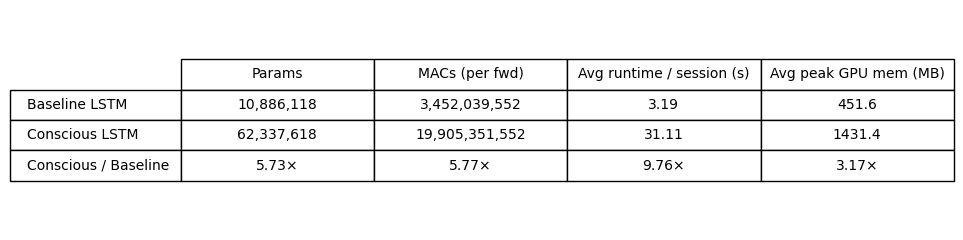

In [13]:
baseline_macs  = 3_452_039_552
conscious_macs = 19_905_351_552

param_ratio = conscious_params / baseline_params if baseline_params > 0 else float("nan")
mac_ratio   = conscious_macs / baseline_macs if baseline_macs > 0 else float("nan")
time_ratio  = conscious_avg_runtime / baseline_avg_runtime if baseline_avg_runtime > 0 else float("nan")

if baseline_avg_peak_mem not in (None, 0):
    mem_ratio = conscious_avg_peak_mem / baseline_avg_peak_mem
else:
    mem_ratio = float("nan")

data = {
    "Params": [
        f"{baseline_params:,}",
        f"{conscious_params:,}",
        f"{param_ratio:.2f}×",
    ],
    "MACs (per fwd)": [
        f"{baseline_macs:,}",
        f"{conscious_macs:,}",
        f"{mac_ratio:.2f}×",
    ],
    "Avg runtime / session (s)": [
        f"{baseline_avg_runtime:.2f}",
        f"{conscious_avg_runtime:.2f}",
        f"{time_ratio:.2f}×",
    ],
    "Avg peak GPU mem (MB)": [
        "N/A" if baseline_avg_peak_mem is None else f"{baseline_avg_peak_mem:.1f}",
        "N/A" if conscious_avg_peak_mem is None else f"{conscious_avg_peak_mem:.1f}",
        "N/A" if baseline_avg_peak_mem is None else f"{mem_ratio:.2f}×",
    ],
}

index = ["Baseline LSTM", "Conscious LSTM", "Conscious / Baseline"]
df = pd.DataFrame(data, index=index)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    rowLabels=df.index,
    colLabels=df.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.tight_layout()
plt.show()